# Varying n

In [5]:
import numpy as np
from MyData import load_xg_dataset
from CluseteringBaseline1 import fair_clustering_baseline_1d
from ClusteringBaseline2 import fairlet_kmeans_bins
from time import time


def binning_bias(D, boundaries, x=0, g=1):
    D = np.asarray(D)
    groups = D[:, g].astype(int)
    bins = np.searchsorted(np.asarray(boundaries), D[:, x], side='right')
    unique_groups = np.unique(groups)
    group_to_idx = {group: idx for idx, group in enumerate(unique_groups)}
    overall = np.zeros(len(unique_groups), dtype=float)
    for group, idx in group_to_idx.items():
        overall[idx] = np.mean(groups == group)

    bias = np.zeros(len(unique_groups), dtype=float)
    for bucket in np.unique(bins):
        mask = bins == bucket
        bucket_size = np.sum(mask)
        if bucket_size == 0:
            continue
        for group, idx in group_to_idx.items():
            bucket_ratio = np.sum(groups[mask] == group) / bucket_size
            bias[idx] = max(bias[idx], abs(bucket_ratio - overall[idx]))
    return np.max(bias), bias


D = load_xg_dataset('datasets/german_credit_data.csv', x_idx=7, g_idx=2)
n = D.shape[0]; k = 3
NoRepeat = 30
NoCases = 5

bias_baseline1 = np.zeros(NoCases, dtype=float)
bias_baseline2 = np.zeros(NoCases, dtype=float)
exec_time_baseline1 = np.zeros(NoCases, dtype=float)
exec_time_baseline2 = np.zeros(NoCases, dtype=float)

for i in range(NoCases):
    nprime = int((n / NoCases) * (i + 1))
    for rep in range(NoRepeat):
        np.random.seed(rep)
        idx = np.random.choice(D.shape[0], nprime, replace=True)
        D_sample = D[idx]
        x_sample = D_sample[:, 0]
        g_sample = D_sample[:, 1].astype(int)
        unique_groups = np.unique(g_sample)
        group_membership = [tuple(int(group == value) for group in unique_groups) for value in g_sample]
        requirements = np.ones(len(unique_groups), dtype=int)

        t = time()
        result1 = fair_clustering_baseline_1d(x_sample, group_membership, requirements, k)
        exec_time_baseline1[i] += time() - t
        bias_baseline1[i] += binning_bias(D_sample, result1['boundaries'])[0]
        print(f"Case {i}, Repeat {rep}: Baseline 1 - Bias: {bias_baseline1[i]:.4f}, Time: {exec_time_baseline1[i]:.4f}")

        t = time()
        result2 = fairlet_kmeans_bins(x_sample, g_sample, k, random_state=rep)
        exec_time_baseline2[i] += time() - t
        bias_baseline2[i] += binning_bias(D_sample, result2['boundaries'])[0]
        print(f"Case {i}, Repeat {rep}: Baseline 2 - Bias: {bias_baseline2[i]:.4f}, Time: {exec_time_baseline2[i]:.4f}")

    bias_baseline1[i] /= NoRepeat
    bias_baseline2[i] /= NoRepeat
    exec_time_baseline1[i] /= NoRepeat
    exec_time_baseline2[i] /= NoRepeat


/.../UnbiasedBinningPrivate/Python/MyData.py:75: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  g = g_raw.replace(g_mapping).values


Case 0, Repeat 0: Baseline 1 - Bias: 0.1205, Time: 0.4373
Case 0, Repeat 0: Baseline 2 - Bias: 0.2231, Time: 0.0067
Case 0, Repeat 1: Baseline 1 - Bias: 0.1784, Time: 0.8824
Case 0, Repeat 1: Baseline 2 - Bias: 0.3714, Time: 0.0142
Case 0, Repeat 2: Baseline 1 - Bias: 0.3510, Time: 1.1564
Case 0, Repeat 2: Baseline 2 - Bias: 0.5164, Time: 0.0197
Case 0, Repeat 3: Baseline 1 - Bias: 0.4360, Time: 1.5793
Case 0, Repeat 3: Baseline 2 - Bias: 0.6196, Time: 0.0258
Case 0, Repeat 4: Baseline 1 - Bias: 0.6226, Time: 2.0568
Case 0, Repeat 4: Baseline 2 - Bias: 0.7131, Time: 0.0320
Case 0, Repeat 5: Baseline 1 - Bias: 0.7000, Time: 2.4598
Case 0, Repeat 5: Baseline 2 - Bias: 0.8431, Time: 0.0382
Case 0, Repeat 6: Baseline 1 - Bias: 0.8415, Time: 2.9323
Case 0, Repeat 6: Baseline 2 - Bias: 0.9510, Time: 0.0435
Case 0, Repeat 7: Baseline 1 - Bias: 0.8965, Time: 3.4596
Case 0, Repeat 7: Baseline 2 - Bias: 1.0137, Time: 0.0497
Case 0, Repeat 8: Baseline 1 - Bias: 0.9642, Time: 3.7247
Case 0, Repeat

In [4]:
# print('n:', n)
# print('bias_baseline1:', bias_baseline1)
# print('exec_time_baseline1:', exec_time_baseline1)
# print('bias_baseline2:', bias_baseline2)
# print('exec_time_baseline2:', exec_time_baseline2)

k = 3
NoRepeat = 30
NoCases = 5
n= 1000
bias_baseline1 = [0.09638528, 0.08434935, 0.08394544, 0.08540871, 0.08914419]
exec_time_baseline1 = [0.38855271, 1.82998464, 5.21441864, 9.96814004, 16.31824079]
bias_baseline2 = [0.10602737, 0.11538569, 0.11285325, 0.10787614, 0.11145334]
exec_time_baseline2 = [0.00802849, 0.01296482, 0.01399508, 0.01891352, 0.01842988]


/var/folders/20/rbpk_t391yq6s7bk8mry_6180000gn/T/ipykernel_42368/364191460.py:30: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 1.1 * max(np.max(exec_time_baseline1), np.max(exec_time_baseline2)))


<Figure size 500x400 with 0 Axes>

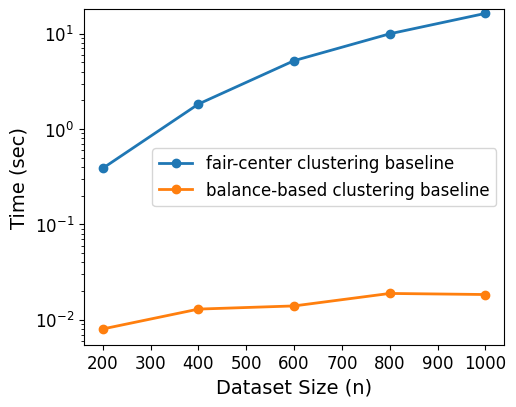

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Data
xaxis = [int((n / NoCases) * (i + 1)) for i in range(NoCases)]

# Plot settings
plt.figure(figsize=(5, 4))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.plot(xaxis, bias_baseline1, marker='o', color='#1f77b4', linewidth=2, markersize=6, label='fair-center clustering baseline')
plt.plot(xaxis, bias_baseline2, marker='o', color='#ff7f0e', linewidth=2, markersize=6, label='balance-based clustering baseline')
plt.xlabel('Dataset Size (n)', fontsize=14)
plt.ylabel('Bias', fontsize=14)
plt.ylim(0, 1.1 * max(np.max(bias_baseline1), np.max(bias_baseline2)))
plt.legend(fontsize=12)
plt.savefig('exp/unbiased/germancredit/clustering_bias_vs_n.pdf', format='pdf', bbox_inches='tight')
plt.clf()

plt.figure(figsize=(5, 4))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.plot(xaxis, exec_time_baseline1, marker='o', color='#1f77b4', linewidth=2, markersize=6, label='fair-center clustering baseline')
plt.plot(xaxis, exec_time_baseline2, marker='o', color='#ff7f0e', linewidth=2, markersize=6, label='balance-based clustering baseline')
plt.xlabel('Dataset Size (n)', fontsize=14)
plt.yscale('log')
plt.ylabel('Time (sec)', fontsize=14)
plt.ylim(0, 1.1 * max(np.max(exec_time_baseline1), np.max(exec_time_baseline2)))
plt.legend(fontsize=12)
plt.savefig('exp/unbiased/germancredit/clustering_time_vs_n.pdf', format='pdf', bbox_inches='tight')
